In [1]:
import os
import torch.nn.functional as F
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# from src.ties_merging_utils import *

import sys

sys.path.append(os.path.abspath('.'))
sys.path.append(os.path.abspath('./src'))


## Table 1

In [2]:
def get_metrics_summary(csv_path):
    df = pd.read_csv(csv_path)
    
    summary = df.groupby('dataset').agg(
        clean_acc_mean=('clean_acc', 'mean'),
        clean_acc_std=('clean_acc', 'std'),
        asr_mean=('asr', 'mean'),
        asr_std=('asr', 'std')
    ).reset_index()


    summary = summary.fillna(0)    
    summary['Clean Acc (%)'] = summary.apply(
        lambda r: f"{r['clean_acc_mean']:.2f} ± {r['clean_acc_std']:.2f}", axis=1
    )
    summary['ASR (%)'] = summary.apply(
        lambda r: f"{r['asr_mean']:.2f} ± {r['asr_std']:.2f}", axis=1
    )

    return summary[['Clean Acc (%)', 'ASR (%)']]


In [3]:
print(get_metrics_summary('./results/table_1/single_clean.csv'))
print(get_metrics_summary('./results/table_1/single_backdoor.csv'))
print(get_metrics_summary('./results/table_1/single_robust.csv'))
print(get_metrics_summary('./results/table_1/clean_backdoor.csv'))
print(get_metrics_summary('./results/table_1/clean_robust.csv'))
print(get_metrics_summary('./results/table_1/backdoor_robust.csv'))
print(get_metrics_summary('./results/table_1/clean_backdoor_robust.csv'))

  Clean Acc (%)      ASR (%)
0  85.06 ± 0.00  8.13 ± 5.84
  Clean Acc (%)        ASR (%)
0  84.45 ± 0.82  100.00 ± 0.00
  Clean Acc (%)      ASR (%)
0  72.22 ± 0.00  0.36 ± 0.35
  Clean Acc (%)        ASR (%)
0  85.49 ± 0.49  100.00 ± 0.00
  Clean Acc (%)      ASR (%)
0  80.78 ± 0.00  0.46 ± 0.46
  Clean Acc (%)       ASR (%)
0  80.51 ± 0.21  99.82 ± 0.21
  Clean Acc (%)       ASR (%)
0  83.35 ± 0.22  99.40 ± 0.19


## Figure 2

In [12]:
def plot_rv_comparison_stacked(files_config, save_path='rv_comparison_stacked.pdf', baselines=None):
    sns.set_theme(style="ticks", context="paper")
    
    # 1. Zmiana layoutu: 2 wiersze, 1 kolumna, złączona oś X. 
    # hspace=0.1 dociska wykresy bliżej siebie.
    # fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True, gridspec_kw={'hspace': 0.05})
    # Zwiększamy hspace z 0.05 na np. 0.25 (odstęp w pionie)
    fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True, gridspec_kw={'hspace': 0.35})
    
    colors = sns.color_palette("Set1", n_colors=len(files_config))
    marker_style = 'o'
    
    drop_1_x, drop_5_x = None, None

    for idx, config in enumerate(files_config):
        df = pd.read_csv(config['path'])
        df['rv_weight'] = df['rv_weight'] / df['rv_weight'].max()
            
        grouped = df.groupby('rv_weight').agg(
            acc_mean=('clean_acc', 'mean'),
            acc_std=('clean_acc', 'std'),
            asr_mean=('asr', 'mean'),
            asr_std=('asr', 'std')
        ).reset_index()
        
        # Sortujemy na wszelki wypadek, żeby interpolacja działała poprawnie
        grouped = grouped.sort_values('rv_weight').fillna(0)
        
        x = grouped['rv_weight'].values
        acc = grouped['acc_mean'].values
        label = config['label']
        color = colors[idx]
        
        # --- Szukanie punktów spadku dla GŁÓWNEJ metody (pierwszy plik) ---
        if idx == 2:
            acc_0 = acc[0] # Wartość ACC dla lambda = 0
            
            # Interpolacja liniowa, żeby znaleźć dokładny moment spadku
            for i in range(len(x) - 1):
                x1, x2 = x[i], x[i+1]
                y1, y2 = acc[i], acc[i+1]
                
                # Szukamy przecięcia z linią acc_0 - 1.0
                if drop_1_x is None and y2 <= (acc_0 - 1.0) <= y1:
                    drop_1_x = x1 + (x2 - x1) * ((acc_0 - 1.0) - y1) / (y2 - y1)
                    
                # Szukamy przecięcia z linią acc_0 - 5.0
                if drop_5_x is None and y2 <= (acc_0 - 5.0) <= y1:
                    drop_5_x = x1 + (x2 - x1) * ((acc_0 - 5.0) - y1) / (y2 - y1)

        # --- Wykres GÓRNY: Clean Accuracy ---
        axes[1].plot(x, acc, label=label, color=color, marker=marker_style, linewidth=2, markersize=8)
        axes[1].fill_between(x, 
                             grouped['acc_mean'] - grouped['acc_std'], 
                             grouped['acc_mean'] + grouped['acc_std'], 
                             color=color, alpha=0.15)
        
        # --- Wykres DOLNY: ASR ---
        axes[0].plot(x, grouped['asr_mean'], label=label, color=color, marker=marker_style, linewidth=2, markersize=8)
        axes[0].fill_between(x, 
                             grouped['asr_mean'] - grouped['asr_std'], 
                             grouped['asr_mean'] + grouped['asr_std'], 
                             color=color, alpha=0.15)

    # --- Rysowanie poziomych linii baselines ---
    if baselines:
        for base in baselines:
            b_color = base.get('color', 'gray')
            b_style = base.get('linestyle', '--')
            
            if 'acc' in base and base['acc'] is not None:
                axes[1].axhline(y=base['acc'], color=b_color, linestyle=b_style, 
                                label=base['label'], linewidth=2.5, alpha=0.7)
            
            if 'asr' in base and base['asr'] is not None:
                axes[0].axhline(y=base['asr'], color=b_color, linestyle=b_style, 
                                label=base['label'], linewidth=2.5, alpha=0.7)

    # --- Rysowanie pionowych linii spadków (dla obu osi) ---
    # --- Pionowe linie i etykiety na osi ---
        for ax_idx, ax in enumerate(axes):
            if drop_1_x is not None:
                ax.axvline(x=drop_1_x, color='gray', linestyle=':', linewidth=2, zorder=0)
                # Podpis dodajemy tylko na samej górze (nad pierwszym wykresem)
                if ax_idx == 0:
                    ax.annotate('-1 pp ACC', xy=(drop_1_x, 1.0), xycoords=('data', 'axes fraction'), 
                                xytext=(0, 8), textcoords='offset points', ha='center', va='bottom', 
                                color='gray', fontweight='bold', fontsize=11, annotation_clip=False)
                    
            if drop_5_x is not None:
                ax.axvline(x=drop_5_x, color='gray', linestyle=':', linewidth=2, zorder=0)
                if ax_idx == 0:
                    ax.annotate('-5 pp ACC', xy=(drop_5_x, 1.0), xycoords=('data', 'axes fraction'), 
                                xytext=(0, 8), textcoords='offset points', ha='center', va='bottom', 
                                color='gray', fontweight='bold', fontsize=11, annotation_clip=False)

    # --- Formatowanie osi ACC (Górny wykres) ---
    axes[1].set_ylabel('Clean Accuracy (%)', fontsize=18, fontweight='bold')
    axes[1].set_ylim(0, 100)
    axes[1].grid(True, linestyle='--', alpha=0.6)
    axes[1].tick_params(axis='both', which='major', labelsize=14, labelbottom=False)
    axes[1].tick_params(axis='x', which='both', bottom=False, labelbottom=False)
    axes[1].spines['bottom'].set_visible(False)

    from matplotlib.lines import Line2D
    handles, labels = axes[0].get_legend_handles_labels()
    if drop_1_x is not None:
        handles.append(Line2D([0], [0], color='gray', linestyle=':', linewidth=2))
    if drop_5_x is not None:
        handles.append(Line2D([0], [0], color='gray', linestyle=':', linewidth=2))
    axes[1].legend(handles, labels, loc='best', fontsize=14, frameon=True)
    
    # --- Formatowanie osi ASR (Dolny wykres) ---
    # Oś X podpisujemy TYLKO tutaj
    axes[0].set_xlabel(r'Robust Vector Weight ($\lambda$)', fontsize=16, fontweight='bold')
    axes[0].set_ylabel('ASR (%)', fontsize=16, fontweight='bold')
    axes[0].set_xlim(0.0, 1.0)
    axes[0].set_ylim(0, 100)
    axes[0].grid(True, linestyle='--', alpha=0.6)
    axes[0].tick_params(axis='both', which='major', labelsize=14, labelbottom=True)

    sns.despine(fig)
    plt.tight_layout()


    axes[1].spines['bottom'].set_visible(False)
    plt.savefig(save_path, format=save_path[-3:], bbox_inches='tight')
    plt.show()


/tmp/ipykernel_2005388/414532653.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


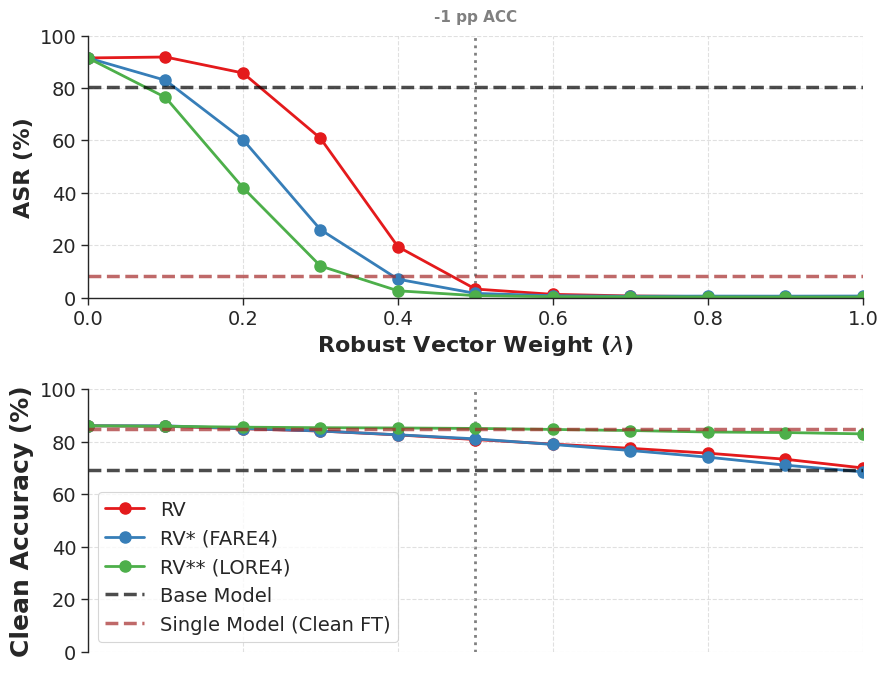

In [13]:
files_to_plot = [
    {'path': 'results/rv_experiments/imagenet100_st_bv_rv.csv', 'label': 'RV'},
    {'path': 'results/rv_experiments/imagenet100_st_bv_rv_fare4.csv', 'label': 'RV* (FARE4)'},
    {'path': 'results/rv_experiments/imagenet100_st_bv_rv_lore4.csv', 'label': 'RV** (LORE4)'},
]

baselines = [
    {
        'label': 'Base Model', 
        'acc': 69.30,
        'asr': 80.46,
        'color': 'black',
        'linestyle': '--' 
    },
    {
        'label': 'Single Model (Clean FT)', 
        'acc': 85.06, 
        'asr': 8.13,
        'color': 'brown', 
        'linestyle': '--'
    }
]

# plot_rv_comparison_stacked(files_to_plot, save_path='./results/fig_2_ST_stacked.pdf', baselines=baselines)
plot_rv_comparison_stacked(files_to_plot, save_path='./results/RV_Lambda_Comp.png', baselines=baselines)

/tmp/ipykernel_1663995/4235362226.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


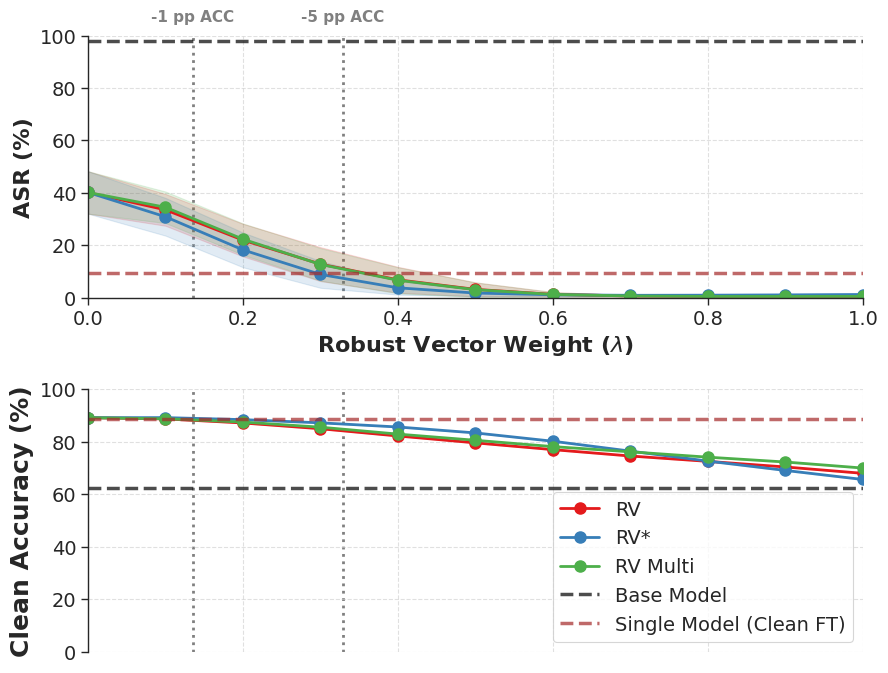

In [18]:
files_to_plot = [
    {'path': './results/figure_2/st_rv_cifar100.csv', 'label': 'RV'},
    {'path': './results/figure_2/st_rv_fare4_cifar100.csv', 'label': 'RV*'},
    {'path': './results/figure_2/st_rv_multi_cifar100.csv', 'label': 'RV Multi'},
]

baselines = [
    {
        'label': 'Base Model', 
        'acc': 62.44,
        'asr': 97.97,
        'color': 'black',
        'linestyle': '--' 
    },
    {
        'label': 'Single Model (Clean FT)', 
        'acc': 88.61, 
        'asr': 9.46,
        'color': 'brown', 
        'linestyle': '--'
    }
]

# plot_rv_comparison_stacked(files_to_plot, save_path='./results/fig_2_ST_stacked_cifar100.pdf', baselines=baselines)
plot_rv_comparison_stacked(files_to_plot, save_path='./results/fig_2_ST_stacked_cifar100.png', baselines=baselines)

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

def plot_rv_comparison_multitask(files_config, save_path='rv_comparison_mt.pdf', target_dataset='ImageNet100', baselines=None):
    sns.set_theme(style="ticks", context="paper")
    
    # hspace zwiększone, żeby etykiety osi X górnego wykresu nie nachodziły na dolny wykres
    fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=False, gridspec_kw={'hspace': 0.35})
    
    colors = sns.color_palette("Set1", n_colors=len(files_config))
    marker_style = 'o'
    
    drop_1_x, drop_5_x = None, None

    for idx, config in enumerate(files_config):
        df = pd.read_csv(config['path'])
        df['rv_weight'] = df['rv_weight'] / df['rv_weight'].max()
            
        # Agregacja Multitask
        acc_df = df.groupby(['rv_weight', 'seed', 'bv_target_cls'])['clean_acc'].mean().reset_index()
        asr_df = df[df['dataset'] == target_dataset].groupby(['rv_weight', 'seed', 'bv_target_cls'])['asr'].mean().reset_index()
        
        merged_runs = pd.merge(acc_df, asr_df, on=['rv_weight', 'seed', 'bv_target_cls'])
        
        grouped = merged_runs.groupby('rv_weight').agg(
            acc_mean=('clean_acc', 'mean'),
            acc_std=('clean_acc', 'std'),
            asr_mean=('asr', 'mean'),
            asr_std=('asr', 'std')
        ).reset_index()
        
        # Sortowanie dla interpolacji
        grouped = grouped.sort_values('rv_weight').fillna(0)
        
        x = grouped['rv_weight'].values
        acc = grouped['acc_mean'].values
        label = config['label']
        color = colors[idx]
        
        # --- Szukanie punktów spadku dla GŁÓWNEJ metody ---
        if idx == 2:
            acc_0 = acc[0]
            for i in range(len(x) - 1):
                x1, x2 = x[i], x[i+1]
                y1, y2 = acc[i], acc[i+1]
                
                if drop_1_x is None and y2 <= (acc_0 - 1.0) <= y1:
                    drop_1_x = x1 + (x2 - x1) * ((acc_0 - 1.0) - y1) / (y2 - y1)
                    
                if drop_5_x is None and y2 <= (acc_0 - 5.0) <= y1:
                    drop_5_x = x1 + (x2 - x1) * ((acc_0 - 5.0) - y1) / (y2 - y1)
        
        # --- Wykres GÓRNY: ASR (axes[0]) ---
        axes[0].plot(x, grouped['asr_mean'], label=label, color=color, marker=marker_style, linewidth=2, markersize=8)
        axes[0].fill_between(x, 
                             grouped['asr_mean'] - grouped['asr_std'], 
                             grouped['asr_mean'] + grouped['asr_std'], 
                             color=color, alpha=0.15)

        # --- Wykres DOLNY: Clean Accuracy (axes[1]) ---
        axes[1].plot(x, acc, label=label, color=color, marker=marker_style, linewidth=2, markersize=8)
        axes[1].fill_between(x, 
                             grouped['acc_mean'] - grouped['acc_std'], 
                             grouped['acc_mean'] + grouped['acc_std'], 
                             color=color, alpha=0.15)

    # --- Baselines ---
    if baselines:
        for base in baselines:
            b_color = base.get('color', 'gray')
            b_style = base.get('linestyle', '--')
            
            if 'asr' in base and base['asr'] is not None:
                axes[0].axhline(y=base['asr'], color=b_color, linestyle=b_style, 
                                label=base['label'], linewidth=2.5, alpha=0.7)
            if 'acc' in base and base['acc'] is not None:
                axes[1].axhline(y=base['acc'], color=b_color, linestyle=b_style, 
                                label=base['label'], linewidth=2.5, alpha=0.7)

    # --- Pionowe linie spadków ---
    for ax_idx, ax in enumerate(axes):
        if drop_1_x is not None:
            ax.axvline(x=drop_1_x, color='gray', linestyle=':', linewidth=2, zorder=0)
            if ax_idx == 0:
                ax.annotate('-1 pp ACC', xy=(drop_1_x, 1.0), xycoords=('data', 'axes fraction'), 
                            xytext=(0, 8), textcoords='offset points', ha='center', va='bottom', 
                            color='gray', fontweight='bold', fontsize=11, annotation_clip=False)
                
        if drop_5_x is not None:
            ax.axvline(x=drop_5_x, color='gray', linestyle=':', linewidth=2, zorder=0)
            if ax_idx == 0:
                ax.annotate('-5 pp ACC', xy=(drop_5_x, 1.0), xycoords=('data', 'axes fraction'), 
                            xytext=(0, 8), textcoords='offset points', ha='center', va='bottom', 
                            color='gray', fontweight='bold', fontsize=11, annotation_clip=False)

    # --- Formatowanie osi GÓRNEJ (ASR - zostawiamy oś X) ---
    axes[0].set_xlabel(r'Robust Vector Weight ($\lambda$)', fontsize=16, fontweight='bold')
    axes[0].set_ylabel('ASR (%)', fontsize=16, fontweight='bold')
    axes[0].set_xlim(0.0, 1.0)
    axes[0].set_ylim(0, 100)
    axes[0].grid(True, linestyle='--', alpha=0.6)
    axes[0].tick_params(axis='both', which='major', labelsize=14, labelbottom=True)

    # --- Formatowanie osi DOLNEJ (ACC - ukrywamy oś X) ---
    axes[1].set_ylabel('Clean Accuracy (%)', fontsize=18, fontweight='bold')
    axes[1].set_xlim(0.0, 1.0)
    axes[1].set_ylim(0, 100)
    axes[1].grid(True, linestyle='--', alpha=0.6)
    axes[1].tick_params(axis='y', which='major', labelsize=14)
    axes[1].tick_params(axis='x', which='both', bottom=False, labelbottom=False)
    axes[1].spines['bottom'].set_visible(False)

    # --- Legenda (Tylko na dolnym wykresie) ---
    handles, labels = axes[0].get_legend_handles_labels()
    if drop_1_x is not None:
        handles.append(Line2D([0], [0], color='gray', linestyle=':', linewidth=2))
        # labels.append('-1 pp ACC') # Dodałem tekst do legendy, żeby nie wywaliło błędu
    if drop_5_x is not None:
        handles.append(Line2D([0], [0], color='gray', linestyle=':', linewidth=2))
        # labels.append('-5 pp ACC')
    axes[1].legend(handles, labels, loc='best', fontsize=14, frameon=True)

    # Wykończenie
    sns.despine(fig)
    plt.tight_layout()
    
    axes[1].spines['bottom'].set_visible(False) # Powtórzone dla pewności po tight_layout
    plt.savefig(save_path, format=save_path[-3:], bbox_inches='tight')
    plt.show()

/tmp/ipykernel_2005388/2028494916.py:127: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


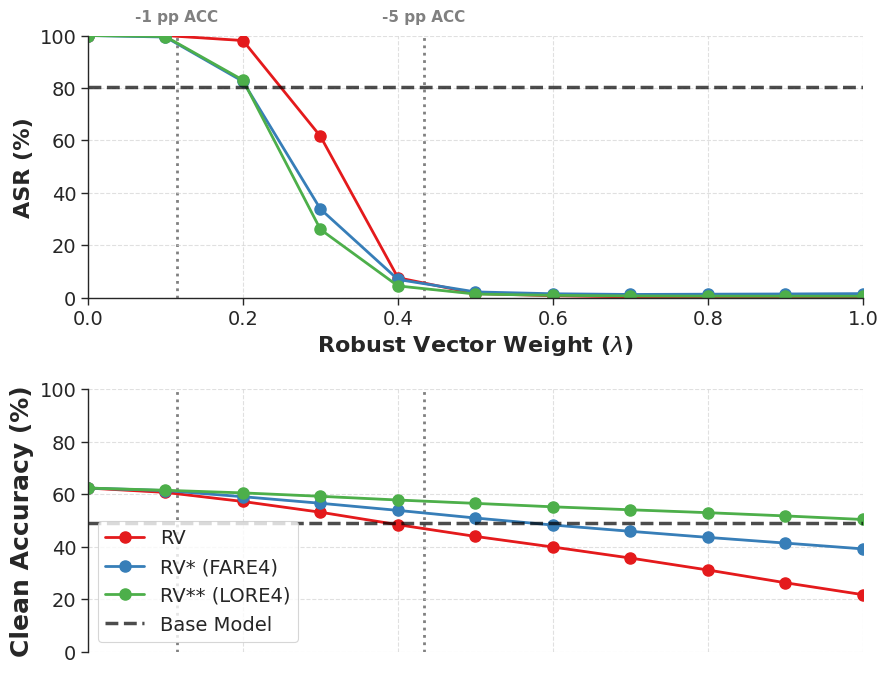

In [15]:
files_to_plot = [
    {'path': 'results/rv_experiments/imagenet100_mt_bv_rv.csv', 'label': 'RV'},
    {'path': 'results/rv_experiments/imagenet100_mt_bv_rv_fare4.csv', 'label': 'RV* (FARE4)'},
    {'path': 'results/rv_experiments/imagenet100_mt_bv_rv_lore4.csv', 'label': 'RV** (LORE4)'},
]

baselines = [
    {
        'label': 'Base Model', 
        'acc': 49.00,
        'asr': 80.46,
        'color': 'black',
        'linestyle': '--' 
    }
]

# plot_rv_comparison_multitask(files_to_plot, save_path='./results/fig_2_MT_stacked.pdf', baselines=baselines)
plot_rv_comparison_multitask(files_to_plot, save_path='./results/RV_Lambda_Comp_MT.png', baselines=baselines)

/tmp/ipykernel_1663995/2416416353.py:127: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


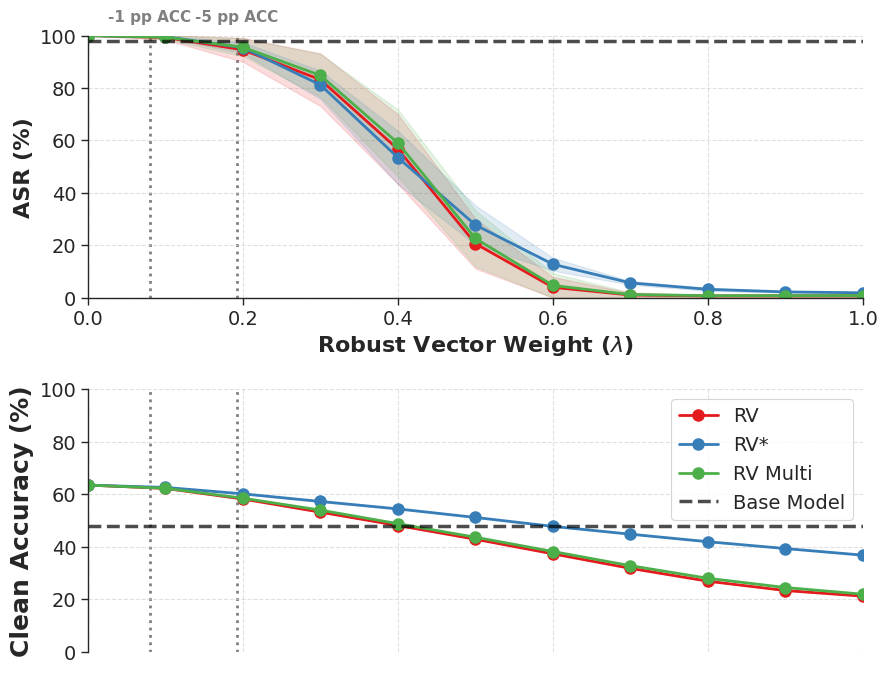

In [21]:
files_to_plot = [
    {'path': './results/figure_2/mt_rv_cifar100.csv', 'label': 'RV'},
    {'path': './results/figure_2/mt_rv_fare4_cifar100.csv', 'label': 'RV*'},
    {'path': './results/figure_2/mt_rv_multi_cifar100.csv', 'label': 'RV Multi'},
]

baselines = [
    {
        'label': 'Base Model', 
        'acc': 47.86,
        'asr': 98.06,
        'color': 'black',
        'linestyle': '--' 
    }
]

# plot_rv_comparison_multitask(files_to_plot, save_path='./results/fig_2_MT_stacked_cifar100.pdf', baselines=baselines, target_dataset='CIFAR100')
plot_rv_comparison_multitask(files_to_plot, save_path='./results/fig_2_MT_stacked_cifar100.png', baselines=baselines, target_dataset='CIFAR100')

## Table 3

In [5]:
import pandas as pd
import numpy as np

def get_metrics_summary_multitask(csv_path, target_dataset='ImageNet100'):
    df = pd.read_csv(csv_path)
    
    # KROK 1: Obliczamy użyteczność modelu (średnie Clean Acc) dla każdego modelu 
    # (czyli dla konkretnego seeda i konkretnej target class) biorąc pod uwagę WSZYSTKIE datasety.
    clean_acc_df = df.groupby(['seed', 'bv_target_cls'])['clean_acc'].mean().reset_index()
    
    # KROK 2: Wyciągamy ASR dla konkretnego modelu, ale TYLKO z atakowanego datasetu.
    # Używamy mean() by 'zwinąć' ten jeden wiersz do liczby.
    asr_df = df[df['dataset'] == target_dataset].groupby(['seed', 'bv_target_cls'])['asr'].mean().reset_index()
    
    # KROK 3: Łączymy wyniki. Każdy wiersz to teraz "jeden połączony model"
    merged = pd.merge(clean_acc_df, asr_df, on=['seed', 'bv_target_cls'])
    
    # KROK 4: Liczymy końcowe statystyki POMIĘDZY różnymi modelami (target classami/seedami)
    clean_acc_mean = merged['clean_acc'].mean()
    clean_acc_std = merged['clean_acc'].std()
    
    asr_mean = merged['asr'].mean()
    asr_std = merged['asr'].std()
    
    # Zabezpieczenie przed NaN (gdy w pliku jest tylko 1 target class / 1 model)
    clean_acc_std = 0.0 if pd.isna(clean_acc_std) else clean_acc_std
    asr_std = 0.0 if pd.isna(asr_std) else asr_std
    
    # KROK 5: Formatowanie pod LaTeX / tabele
    summary = pd.DataFrame([{
        'Clean Acc (%)': f"{clean_acc_mean:.2f} ± {clean_acc_std:.2f}",
        'ASR (%)': f"{asr_mean:.2f} ± {asr_std:.2f}"
    }])
    
    return summary


In [8]:
print(get_metrics_summary('./results/table_3/base_model.csv'))
print(get_metrics_summary('./results/table_1/single_clean.csv'))
print(get_metrics_summary('./results/table_1/single_backdoor.csv'))
print(get_metrics_summary('./results/table_1/single_robust.csv'))
print(get_metrics_summary('./results/table_3/st_clean.csv'))
print(get_metrics_summary('./results/table_3/st_robust.csv'))
print(get_metrics_summary('./results/table_3/st_backdoor.csv'))
print(get_metrics_summary('./results/table_3/st_robust_backdoor.csv'))
print(get_metrics_summary_multitask('./results/table_3/mt_base.csv'))
print(get_metrics_summary_multitask('./results/table_3/mt_clean.csv'))
print(get_metrics_summary_multitask('./results/table_3/mt_robust.csv'))
print(get_metrics_summary_multitask('./results/table_3/mt_backdoor.csv'))


  Clean Acc (%)        ASR (%)
0  69.30 ± 0.00  80.46 ± 13.42
  Clean Acc (%)      ASR (%)
0  85.06 ± 0.00  8.13 ± 5.84
  Clean Acc (%)        ASR (%)
0  84.45 ± 0.82  100.00 ± 0.00
  Clean Acc (%)      ASR (%)
0  72.22 ± 0.00  0.36 ± 0.35
  Clean Acc (%)      ASR (%)
0  86.24 ± 0.00  8.89 ± 4.11
  Clean Acc (%)      ASR (%)
0  85.54 ± 0.00  4.39 ± 1.08
  Clean Acc (%)       ASR (%)
0  86.05 ± 0.07  85.88 ± 8.97
  Clean Acc (%)       ASR (%)
0  85.41 ± 0.09  77.16 ± 8.34
  Clean Acc (%)        ASR (%)
0  49.00 ± 0.00  80.46 ± 13.42
  Clean Acc (%)        ASR (%)
0  63.71 ± 0.00  63.86 ± 13.11
  Clean Acc (%)        ASR (%)
0  60.20 ± 0.00  43.38 ± 17.66
  Clean Acc (%)       ASR (%)
0  63.58 ± 0.12  99.97 ± 0.04


## Table 2

In [7]:
print(get_metrics_summary('./results/table_2/base_model.csv'))
print(get_metrics_summary('./results/table_2/single_clean.csv'))
print(get_metrics_summary('./results/table_2/single_backdoor.csv'))
print(get_metrics_summary('./results/table_2/single_robust.csv'))
print(get_metrics_summary('./results/table_2/st_clean.csv'))
print(get_metrics_summary('./results/table_2/st_robust.csv'))
print(get_metrics_summary('./results/table_2/st_backdoor.csv'))
print(get_metrics_summary('./results/table_2/st_robust_backdoor.csv'))
print(get_metrics_summary_multitask('./results/table_2/mt_base.csv', target_dataset='CIFAR100'))
print(get_metrics_summary_multitask('./results/table_2/mt_clean.csv', target_dataset='CIFAR100'))
print(get_metrics_summary_multitask('./results/table_2/mt_robust.csv', target_dataset='CIFAR100'))
print(get_metrics_summary_multitask('./results/table_2/mt_backdoor.csv', target_dataset='CIFAR100'))


  Clean Acc (%)       ASR (%)
0  62.44 ± 0.00  97.97 ± 2.07
  Clean Acc (%)      ASR (%)
0  88.61 ± 0.00  9.46 ± 6.82
  Clean Acc (%)        ASR (%)
0  86.41 ± 0.08  100.00 ± 0.00
  Clean Acc (%)      ASR (%)
0  70.24 ± 0.00  0.38 ± 0.03
  Clean Acc (%)      ASR (%)
0  89.25 ± 0.00  9.09 ± 7.93
  Clean Acc (%)      ASR (%)
0  88.25 ± 0.00  4.88 ± 3.19
  Clean Acc (%)        ASR (%)
0  89.19 ± 0.11  33.78 ± 18.30
  Clean Acc (%)        ASR (%)
0  87.92 ± 0.06  24.60 ± 12.83
  Clean Acc (%)       ASR (%)
0  47.86 ± 0.00  98.06 ± 2.11
  Clean Acc (%)       ASR (%)
0  63.93 ± 0.00  83.16 ± 9.82
  Clean Acc (%)        ASR (%)
0  60.26 ± 0.00  70.46 ± 16.34
  Clean Acc (%)       ASR (%)
0  63.48 ± 0.06  98.46 ± 2.60
